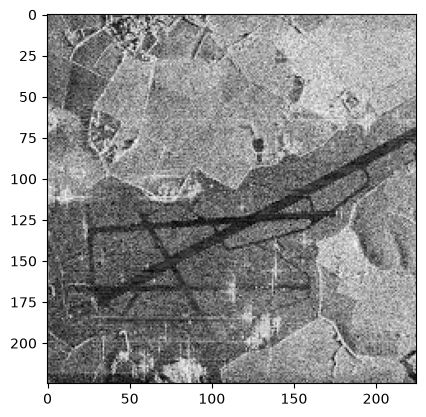

In [3]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import copy
import math

image = cv2.imread('sar_3.jpg')
image_gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

plt.imshow(image_gray, cmap="gray")
plt.show()


In [42]:
c = cv2.Canny(image_gray, 170, 250, apertureSize=3)
lines = cv2.HoughLines(c, 1, np.pi/180, 130)

print("Найдено линий:", len(lines) if lines is not None else 0)

Найдено линий: 1


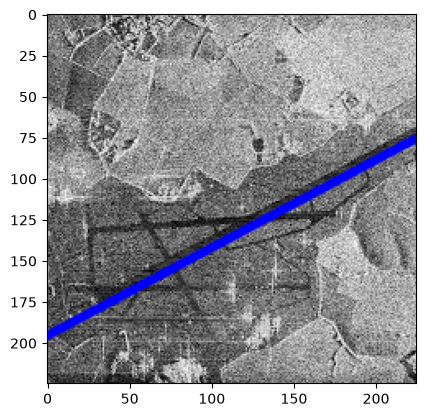

In [43]:
image_color = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

if lines is not None:
    for i in range(0, len(lines)):
        rho = lines[i][0][0]
        theta = lines[i][0][1]
        a = math.cos(theta)
        b = math.sin(theta)
        x0 = a * rho
        y0 = b * rho
        pt1 = (int(x0 + 1000*(-b)), int(y0 + 1000*(a)))
        pt2 = (int(x0 - 1000*(-b)), int(y0 - 1000*(a)))
        cv2.line(image_color, pt1, pt2, (0, 0, 255), 3, cv2.LINE_AA)

plt.imshow(image_res)
plt.show()

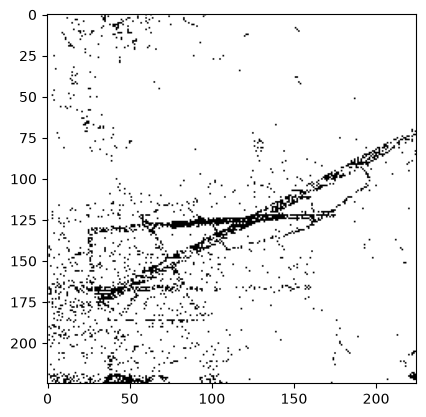

In [38]:
bin_img = copy.deepcopy(image_gray)
T = 50
bin_img[image_gray < T] = 0
bin_img[image_gray >= T] = 255

plt.imshow(bin_img, cmap="gray")
plt.show()

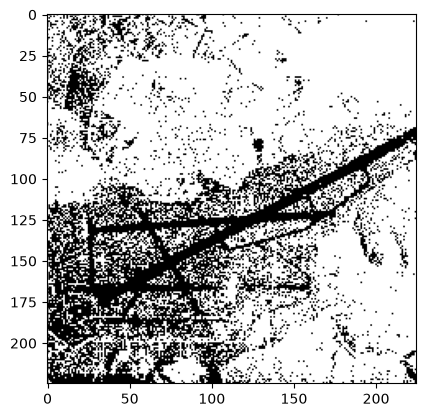

In [41]:
bin_img = copy.deepcopy(image_gray)
T = 100
bin_img[image_gray < T] = 0
bin_img[image_gray >= T] = 255

plt.imshow(bin_img, cmap="gray")
plt.show()

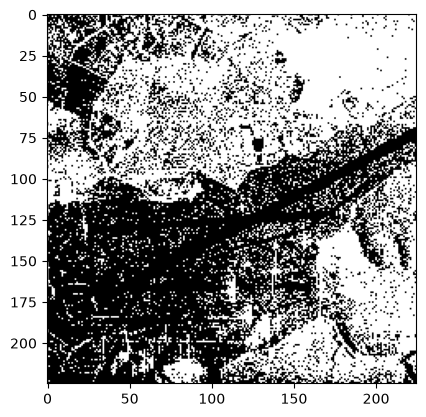

In [36]:
_, th2 = cv2.threshold(image_gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

plt.imshow(th2, cmap="gray")
plt.show()

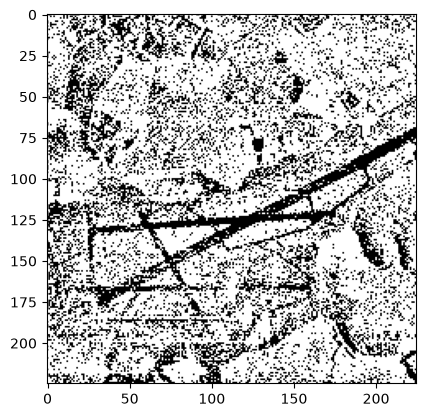

In [37]:
th3 = cv2.adaptiveThreshold(image_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 71, 21)

plt.imshow(th3, cmap="gray")
plt.show()